# GRA: RelSignum + synthetic tests

project = ```GRA```, host = ```mach```, device = ```cuda:0```

## Goals:

In [1]:
# HIDE CODE


project_name = '_GRA'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: mach

## Main

In [3]:
from optimizers import *
from test.test import *

In [4]:
def get_rosenbrock_fun(a: float = 1.0):
    def _rosenbrock(x, y):
        return (a - x)**2 + 100 * (y - x**2)**2

    return _rosenbrock


def run_canyon_experiment(configs=None, a=1.0, steps=3_000):
    print("\n=== Running Canyon (Rosenbrock) ===")
    
    rosenbrock = get_rosenbrock_fun(a=a)

    # Start at a tricky point (-2, 2) far from optimum (1, 1)
    start_x, start_y = -2.0, 2.0
    
    lr = 0.01
    momentum = 0.9
    opt_kws = dict(lr=lr, momentum=momentum)
    
    configs = configs or [
        {'name': 'Signum', 'color': 'dimgrey', **opt_kws},
        {'name': 'Rel Signum (M=10.0)', 'mass': 10.0, 'color': 'b', **opt_kws},
        {'name': 'Rel Signum (M=1.0)', 'mass': 1.0, 'color': 'r', **opt_kws},
        {'name': 'Rel Signum (M=0.1)', 'mass': 0.1, 'color': 'g', **opt_kws},
    ]

    plt.figure(figsize=(10, 8))
    
    # Draw contours
    x = torch.linspace(-2.5, 2.5, 100)
    y = torch.linspace(-1, 3, 100)
    X, Y = torch.meshgrid(x, y)
    Z = rosenbrock(X, Y)
    plt.contour(X, Y, Z, levels=torch.logspace(-1, 3, 20), cmap='Greys', alpha=0.6)
    plt.plot(1, 1, 'r*', markersize=15, label='Global Min')

    for cfg in configs:
        p_x = torch.nn.Parameter(torch.tensor([start_x]))
        p_y = torch.nn.Parameter(torch.tensor([start_y]))

        if cfg['name'].startswith('Signum'):
            opt = SignSGD(
                [p_x, p_y], 
                lr=cfg['lr'], 
                momentum=cfg['momentum'], 
            )
        else:
            opt = RelativisticSignum(
                [p_x, p_y], 
                lr=cfg['lr'], 
                momentum=cfg['momentum'], 
                mass=cfg['mass'],
            )

        path_x, path_y = [], []
        
        for i in range(steps):
            opt.zero_grad()
            loss = rosenbrock(p_x, p_y)
            loss.backward()
            opt.step()
            
            path_x.append(p_x.item())
            path_y.append(p_y.item())
        
        plt.plot(path_x, path_y, label=cfg['name'], color=cfg['color'], alpha=0.6, linewidth=2)
        print(f"{cfg['name']} Final Loss: {loss.item():.6f}")

    plt.title("Trajectory Comparison: Inertial vs Gradient Sourcing")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

=== Running Canyon (Rosenbrock) ===

Signum Final Loss: 0.078115

Rel Signum (M=10.0) Final Loss: 0.051781

Rel Signum (M=1.0) Final Loss: 0.053531

Rel Signum (M=0.1) Final Loss: 0.077861

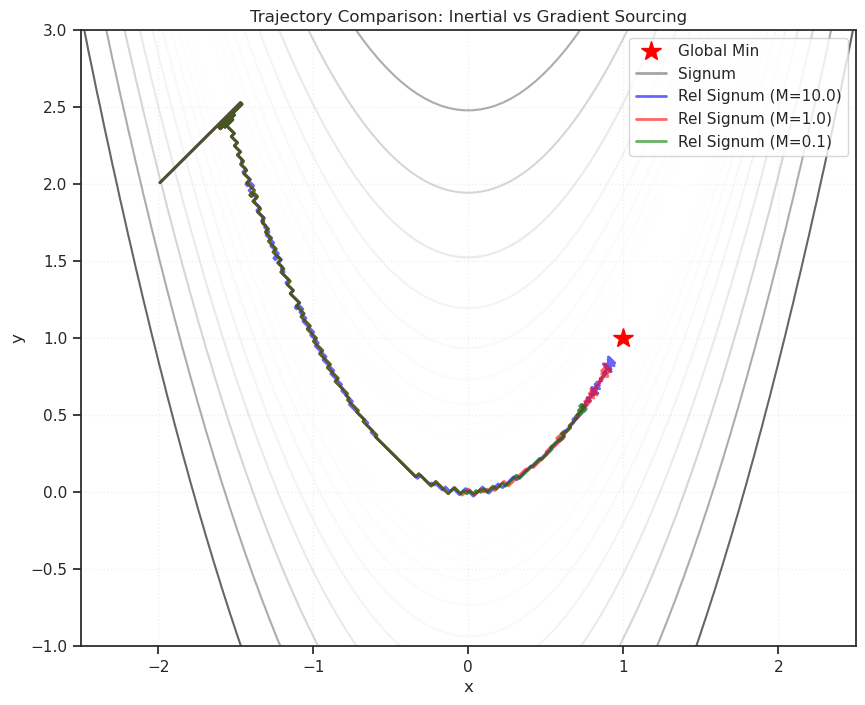

In [5]:
run_canyon_experiment(steps=1000)

In [6]:
def run_heavy_tail_experiment_v2_synchronized(configs=None):
    print("\n=== Running Experiment 1 (Synchronized): Additive Shock Noise ===")
    print("Hypothesis: Finite coupling (Relativistic) prevents 'Variance Poisoning' from outlier shocks.")

    # 1. Setup parameters
    dim = 1
    steps = 1000
    lr = 0.1
    spike_prob = 0.01
    spike_magnitude = 100.0

    start_params = torch.tensor([10.0])
    
    lr = 0.01
    momentum = 0.9
    opt_kws = dict(lr=lr, momentum=momentum)
    configs = configs or [
        {'name': 'Adam', 'color': 'k', 'ls': ':', 'lr': lr, 'betas': (momentum, 0.999)},
        {'name': 'Signum', 'color': 'dimgrey', 'ls': '-', **opt_kws},
        {'name': 'Rel Signum (M=10.0)', 'mass': 10.0, 'color': 'b', **opt_kws},
        {'name': 'Rel Signum (M=1.0)', 'mass': 1.0, 'color': 'r', **opt_kws},
        {'name': 'Rel Signum (M=0.1)', 'mass': 0.1, 'color': 'g', **opt_kws},
    ]

    results = {}

    # 2. Pre-generate spike schedule and noise vectors guarantees synchronization.
    # Set seed once here for the whole experiment's noise generation.
    torch.manual_seed(42)

    spike_map = {}
    dummy_grad = torch.zeros(dim) # Template for noise shape

    print(f"Generating spikes...")
    for i in range(steps):
        # Decide if a spike happens at this step
        if torch.rand(1).item() < spike_prob:
            # Generate the exact noise vector for this step ahead of time
            noise = torch.randn_like(dummy_grad)
            # Normalize and scale to fixed magnitude
            noise = noise / (noise.norm() + 1e-8) * spike_magnitude
            spike_map[i] = noise
            print(f"  Spike scheduled at step {i}")

    # 3. Run loop for each configuration
    for cfg in configs:
        print(f"Running configuration: {cfg['name']}")
        # Reset model parameters to starting point
        params = torch.nn.Parameter(start_params.clone())
        
        

        opt = RelativisticAdam(
            [params],
            lr=lr,
            coupling=cfg['coupling'],
            inertial_sourcing=cfg['inertial']
        )

        losses = []

        # Note: No need to set seed here anymore, as noise is pre-calculated.

        for i in range(steps):
            opt.zero_grad()
            # Simple quadratic loss
            loss = (params ** 2).sum()
            loss.backward()

            # --- Inject synchronized ADDITIVE noise ---
            if i in spike_map:
                with torch.no_grad():
                    # Add the pre-calculated noise vector specific to this step
                    params.grad.add_(spike_map[i])
            # ------------------------------------------

            opt.step()
            losses.append(loss.item())

        results[cfg['name']] = losses

    # 4. Plotting
    plt.figure(figsize=(12, 6))
    for cfg in configs:
        lw = 2 if cfg['coupling'] != float('inf') else 1.5
        plt.plot(results[cfg['name']], label=cfg['name'], color=cfg['color'], linestyle=cfg['ls'], linewidth=lw)

    plt.yscale('log')
    plt.title("Impact of Synchronized Additive Gradient Shocks (Magnitude 100.0)")
    plt.xlabel("Step")
    plt.ylabel("Loss (Log Scale)")
    plt.grid(True, alpha=0.3, which='both')
    plt.legend()

    # Add vertical lines to mark where spikes happened for clarity
    for t in spike_map.keys():
        plt.axvline(x=t, color='r', alpha=0.1, linestyle='-')

    plt.show()

In [7]:
def run_heavy_tail_experiment_v2_synchronized(configs=None):
    print("\n=== Running Experiment 1 (Synchronized): Additive Shock Noise ===")
    print("Hypothesis: Finite coupling (Relativistic) prevents 'Variance Poisoning' from outlier shocks.")

    # 1. Setup parameters
    dim = 1
    steps = 2000
    lr = 0.1
    spike_prob = 0.01
    spike_magnitude = 100.0

    start_params = torch.tensor([10.0])
    
    lr = 0.05
    momentum = 0.9
    opt_kws = dict(lr=lr, momentum=momentum)
    configs = configs or [
        {'name': 'AdamW', 'color': 'k', 'ls': ':', **opt_kws},
        {'name': 'Signum', 'color': 'dimgrey', 'ls': '--', **opt_kws},
        {'name': 'Rel Signum (M=10.0)', 'mass': 10.0, 'color': 'b', 'ls': '-', **opt_kws},
        {'name': 'Rel Signum (M=1.0)', 'mass': 1.0, 'color': 'r', 'ls': '-', **opt_kws},
        {'name': 'Rel Signum (M=0.1)', 'mass': 0.1, 'color': 'g', 'ls': '-', **opt_kws},
    ]

    results = {}

    # 2. Pre-generate spike schedule and noise vectors guarantees synchronization.
    # Set seed once here for the whole experiment's noise generation.
    torch.manual_seed(42)

    spike_map = {}
    dummy_grad = torch.zeros(dim) # Template for noise shape

    print(f"Generating spikes...")
    for i in range(steps):
        # Decide if a spike happens at this step
        if torch.rand(1).item() < spike_prob:
            # Generate the exact noise vector for this step ahead of time
            noise = torch.randn_like(dummy_grad)
            # Normalize and scale to fixed magnitude
            noise = noise / (noise.norm() + 1e-8) * spike_magnitude
            spike_map[i] = noise
            print(f"  Spike scheduled at step {i}")

    # 3. Run loop for each configuration
    for cfg in configs:
        print(f"Running configuration: {cfg['name']}")
        # Reset model parameters to starting point
        params = torch.nn.Parameter(start_params.clone())
        
        if cfg['name'].startswith('AdamW'):
            opt = torch.optim.AdamW(
                [params],
                lr=cfg['lr'], 
                betas=(cfg['momentum'], 0.999), 
            )
        elif cfg['name'].startswith('Signum'):
            opt = SignSGD(
                [params],
                lr=cfg['lr'], 
                momentum=cfg['momentum'], 
            )
        else:
            opt = RelativisticSignum(
                [params],
                lr=cfg['lr'], 
                momentum=cfg['momentum'], 
                mass=cfg['mass'],
            )

        losses = []

        # Note: No need to set seed here anymore, as noise is pre-calculated.

        for i in range(steps):
            opt.zero_grad()
            # Simple quadratic loss
            loss = (params ** 2).sum()
            loss.backward()

            # --- Inject synchronized ADDITIVE noise ---
            if i in spike_map:
                with torch.no_grad():
                    # Add the pre-calculated noise vector specific to this step
                    params.grad.add_(spike_map[i])
            # ------------------------------------------

            opt.step()
            losses.append(loss.item())

        results[cfg['name']] = losses

    # 4. Plotting
    plt.figure(figsize=(12, 6))
    for cfg in configs:
        #lw = 2 if cfg['coupling'] != float('inf') else 1.5
        lw = 1.5
        plt.plot(results[cfg['name']], label=cfg['name'], color=cfg['color'], linestyle=cfg['ls'], linewidth=lw)

    plt.yscale('log')
    plt.title("Impact of Synchronized Additive Gradient Shocks (Magnitude 100.0)")
    plt.xlabel("Step")
    plt.ylabel("Loss (Log Scale)")
    plt.grid(True, alpha=0.3, which='both')
    plt.legend()

    # Add vertical lines to mark where spikes happened for clarity
    for t in spike_map.keys():
        plt.axvline(x=t, color='r', alpha=0.1, linestyle='-')

    plt.show()

=== Running Experiment 1 (Synchronized): Additive Shock Noise ===

Hypothesis: Finite coupling (Relativistic) prevents 'Variance Poisoning' from outlier shocks.

Generating spikes...

Spike scheduled at step 29

Spike scheduled at step 46

...

Running configuration: AdamW

Running configuration: Signum

Running configuration: Rel Signum (M=10.0)

Running configuration: Rel Signum (M=1.0)

Running configuration: Rel Signum (M=0.1)

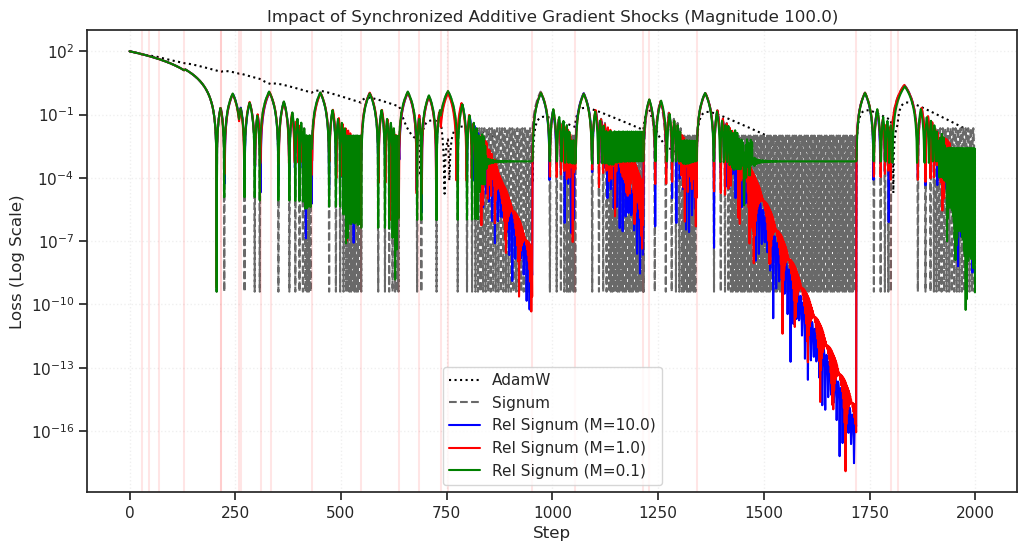

In [8]:
run_heavy_tail_experiment_v2_synchronized()

In [9]:
class CausalSelfAttention(nn.Module):
    def __init__(self, n_embd, n_head, context_len):
        super().__init__()
        assert n_embd % n_head == 0
        self.c_attn = nn.Linear(n_embd, 3 * n_embd)
        self.c_proj = nn.Linear(n_embd, n_embd)
        self.n_head = n_head
        self.n_embd = n_embd
        self.register_buffer("bias", torch.tril(torch.ones(context_len, context_len))
                                     .view(1, 1, context_len, context_len))

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.c_proj(y)

class Block(nn.Module):
    def __init__(self, n_embd, n_head, context_len):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd, n_head, context_len)
        self.ln2 = nn.LayerNorm(n_embd)
        self.mlp = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x


class MiniGPT(nn.Module):
    def __init__(self, vocab_size, n_embd, n_head, n_layer, context_len):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, n_embd)
        self.position_embedding = nn.Embedding(context_len, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head, context_len) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)
        self.context_len = context_len

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)
        x = self.token_embedding(idx) + self.position_embedding(pos)
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        
        loss = None
        if targets is not None:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.reshape(B*T)
            loss = F.cross_entropy(logits, targets)
        return logits, loss


In [10]:
import time
import math


def get_batch(split, batch_size=32, context_len=64, vocab_size=65):
    # Generates synthetic "language-like" data to avoid downloads
    # Pattern: [A, B, C, A, B, C ...] with random noise
    data = torch.randint(0, vocab_size, (batch_size, context_len + 1))
    # Make it learnable: Repeat patterns
    for i in range(batch_size):
        pattern = torch.randint(0, vocab_size, (8,)) # Pattern of length 8
        for j in range(context_len + 1):
            if torch.rand(1) > 0.1: # 90% chance to follow pattern
                data[i,j] = pattern[j % 8]
    
    x = data[:, :context_len]
    y = data[:, 1:]
    return x.to(device), y.to(device)


def run_transformer_experiment(configs=None):
    print("\n=== Experiment 3: The 'No-Warmup' Transformer Test ===")
    print("Hypothesis: RelativisticAdam can survive high-LR initialization without warmup.")
    
    # Model Config
    vocab_size = 65
    n_embd = 128
    n_head = 4
    n_layer = 4
    context_len = 64
    
    # Training Config
    max_iters = 600
    batch_size = 64
    high_lr = 0.01 # Very aggressive for a Transformer
    
    lr = 0.01
    momentum = 0.9
    opt_kws = dict(lr=lr, momentum=momentum)
    configs = configs or [
        {'name': 'AdamW', 'color': 'k', 'ls': ':', **opt_kws},
        {'name': 'Signum', 'color': 'dimgrey', 'ls': '--', **opt_kws},
        {'name': 'Rel Signum (M=10.0)', 'mass': 10.0, 'color': 'b', 'ls': '-', **opt_kws},
        {'name': 'Rel Signum (M=1.0)', 'mass': 1.0, 'color': 'r', 'ls': '-', **opt_kws},
        {'name': 'Rel Signum (M=0.1)', 'mass': 0.1, 'color': 'g', 'ls': '-', **opt_kws},
    ]

    results = {}
    
    # Run comparison
    for cfg in configs:
        print(f"Training {cfg['name']}...")
        torch.manual_seed(1337) # Same init for both
        model = MiniGPT(vocab_size, n_embd, n_head, n_layer, context_len)
        model = model.to(device)
        
        opt = RelativisticAdam(
            model.parameters(),
            lr=high_lr,
            weight_decay=1e-2,
            coupling=cfg['coupling'],
            inertial_sourcing=cfg['inertial'],
            # betas=(0.8, 0.99),
        )

        losses = []
        for iter in range(max_iters):
            x, y = get_batch('train', batch_size, context_len, vocab_size)
            
            
            # Forward
            logits, loss = model(x, y)
            
            # Backward
            opt.zero_grad(set_to_none=True)
            loss.backward()
            
            # Optional: Gradient Clipping is usually standard for Transformers. 
            # We DISABLE it here to let RelAdam do the work.
            # torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            
            opt.step()
            losses.append(loss.item())
            
            if iter % 100 == 0:
                print(f"  Step {iter}: Loss {loss.item():.4f}")
                
        results[cfg['name']] = losses

    # Plot
    plt.figure(figsize=(10, 6))
    for cfg in configs:
        # Smooth the curve slightly for readability
        data = torch.tensor(results[cfg['name']])
        smoothed = data.view(-1, 10).mean(dim=1)
        plt.plot(torch.arange(len(smoothed))*10, smoothed, label=cfg['name'], 
                 color=cfg['color'], linestyle=cfg['ls'], linewidth=2)
        
    plt.title(f"Transformer Training Stability (High LR={high_lr}, No Warmup)")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [11]:
# run_transformer_experiment()

## Outlier test

In [12]:
def generate_data(
    n_samples=200,
    outlier_ratio=0.1,
    outlier_magnitude_min=2.0,
    outlier_magnitude_max=8.0, ):

    # True function: y = sin(3x)
    x = torch.linspace(-3, 3, n_samples).unsqueeze(1)
    y = torch.sin(3 * x)

    # Add small background noise
    y = y + torch.randn_like(y) * 0.1

    # Add outliers
    n_outliers = int(n_samples * outlier_ratio)
    indices = torch.randperm(n_samples)[:n_outliers]

    # Random sign (+/- 1)
    sign = (torch.randint(0, 2, (n_outliers, 1), device=y.device).float() * 2 - 1)

    # Magnitude sampled uniformly in [min, max]
    mag = torch.empty((n_outliers, 1), device=y.device).uniform_(
        float(outlier_magnitude_min), float(outlier_magnitude_max)
    )

    y[indices] = y[indices] + sign * mag
    return x, y, indices


def compute_r2(true, pred):
    ss_res = (true - pred).pow(2)
    ss_tot = (true - true.mean()).pow(2)
    ss_res = torch.sum(ss_res)
    ss_tot = torch.sum(ss_tot)
    # compute r2
    eps = torch.finfo(torch.float32).eps
    r2 = 1.0 - ss_res / (ss_tot + eps)
    return r2

In [75]:
def run_coupling_ablation(
        n_steps=10000,
        n_samples=100,
        outlier_ratio=0.15,
        outlier_mag_max=5.0,
        couplings=None,
        lr=0.01, ):
    print("\n=== Experiment 4: Coupling Ablation (Robust Regression) ===")
    # print("Hypothesis: C ~ 1.0 filters outliers best. C=inf overfits them. C=0.1 learns too slow.")

    # Data
    x_train, y_train, outlier_idx = generate_data(
        n_samples=n_samples,
        outlier_ratio=outlier_ratio,
        outlier_magnitude_max=outlier_mag_max,
        outlier_magnitude_min=2.0,
    )
    
    # "Clean" test set (ground truth) to measure true performance
    x_test = torch.linspace(-3, 3, 200).unsqueeze(1)
    y_test = torch.sin(3 * x_test)

    # Configs to test
    couplings = couplings or [1e-4, 1e-3, 1e-2, 0.05, 0.1, 1.0, 5.0, float('inf')]
    colors = list(sns.color_palette('tab10', n_colors=len(couplings)))
    labels = [f'C={str(c)}' for c in couplings]

    plt.figure(figsize=(20, 9))
    
    # Subplot 1: The fitted curves
    plt.subplot(1, 2, 1)
    plt.scatter(x_train, y_train, c='gray', alpha=0.3, label='Noisy Data')
    plt.scatter(x_train[outlier_idx], y_train[outlier_idx], c='black', marker='x', label='Outliers')
    plt.plot(x_test, y_test, 'k--', linewidth=1, label='True Function')
    
#     x_train = x_train.to(device)
#     y_train = y_train.to(device)
#     x_test = x_test.to(device)
#     y_test = y_test.to(device)

    results = {}

    for i, C in enumerate(couplings):
        # Simple MLP
        model = nn.Sequential(
            nn.Linear(1, 512),
            nn.SiLU(),
            nn.Linear(512, 512),
            nn.SiLU(),
            nn.Linear(512, 1)
        ) # .to(device)
        
        # Note: inertial_sourcing=False matches Adam exactly when C=inf
        opt = RelativisticAdam(
            model.parameters(),
            lr=lr,
            coupling=C, 
            inertial_sourcing=False,
            weight_decay=1e-4,
        )

        losses = []
        test_errors = []

        for step in range(n_steps):
            # Full batch gradient descent
            y_pred = model(x_train)
            loss = nn.MSELoss()(y_pred, y_train)

            opt.zero_grad()
            loss.backward()
            opt.step()

            # Evaluate on clean data
            with torch.no_grad():
                test_pred = model(x_test)
                test_mse = nn.MSELoss()(test_pred, y_test)
                test_errors.append(test_mse.item())

        # Plot final curve
        with torch.no_grad():
            final_pred = model(x_test)
            plt.plot(x_test, final_pred, color=colors[i], linewidth=2, label=labels[i])

        results[labels[i]] = test_errors
        
        test_r = sp_stats.pearsonr(tonp(y_test.squeeze()), tonp(final_pred.squeeze())).statistic
        test_r2 = compute_r2(true=y_test, pred=final_pred)
        if test_r2 < 0:
            r2_str = 'N/A'
        else:
            r2_str = f"{np.round(test_r2 * 100)} %"
        print(f"C={C} done...\t final test MSE = {test_mse.item():0.3f}   ———   r: {test_r:0.2f}  r2: {r2_str}")

    
    plt.title("Final Model Fits vs. Outliers")
    plt.legend()
    # plt.ylim(-2.5, 2.5) # Zoom in to see the fit, ignore outlier range

    # Subplot 2: Test Error Curves
    plt.subplot(1, 2, 2)
    for label, errors in results.items():
        # Smoothing
        smoothed = torch.tensor(errors).view(-1, 10).mean(dim=1)
        plt.plot(smoothed, label=label, linewidth=2)
    
    plt.yscale('log')
    plt.title("Clean Test Set Error (Convergence)")
    plt.xlabel("Step (x10)")
    plt.ylabel("MSE on True Function")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    
    return results

=== Experiment 4: Coupling Ablation (Robust Regression) ===

C=0.0001 done...         final test MSE = 0.029   ———   r: 0.98  r2: 94.0 %

C=0.001 done...  final test MSE = 0.094   ———   r: 0.93  r2: 82.0 %

C=0.01 done...   final test MSE = 0.112   ———   r: 0.93  r2: 78.0 %

C=1.0 done...    final test MSE = 0.368   ———   r: 0.79  r2: 29.0 %

C=100 done...    final test MSE = 0.279   ———   r: 0.82  r2: 46.0 %

C=inf done...    final test MSE = 0.235   ———   r: 0.84  r2: 55.0 %

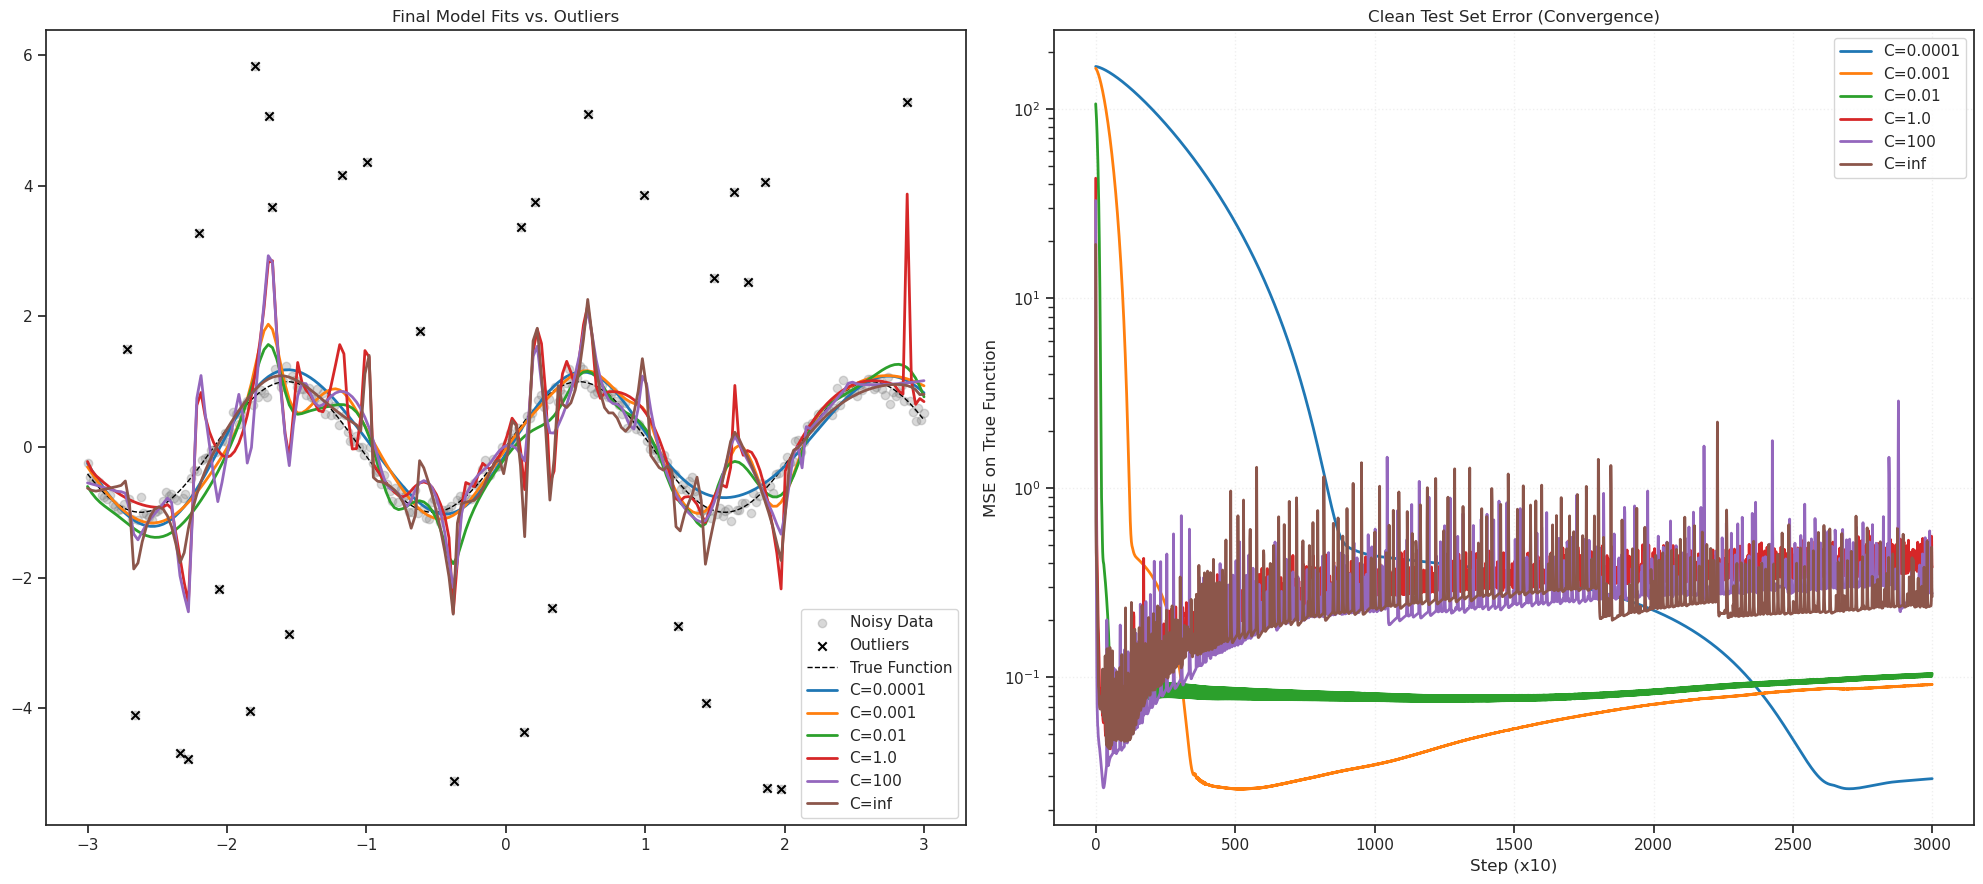

CPU times: user 3h 34min 49s, sys: 5.63 s, total: 3h 34min 55s
Wall time: 6min 43s


In [78]:
%%time


couplings = [1e-4, 1e-3, 1e-2, 1.0, 100, float('inf')]

results2 = run_coupling_ablation(
    n_samples=300,
    outlier_ratio=0.1,
    outlier_mag_max=5.0,
    couplings=couplings,
    n_steps=30_000,
    lr=0.01,
)

=== Experiment 4: Coupling Ablation (Robust Regression) ===

Hypothesis: C ~ 1.0 filters outliers best. C=inf overfits them. C=0.1 learns too slow.

Training with Coupling C=0.0001...

Training with Coupling C=0.001...

Training with Coupling C=0.01...

Training with Coupling C=0.05...

Training with Coupling C=0.1...

Training with Coupling C=1.0...

Training with Coupling C=5.0...

Training with Coupling C=inf...

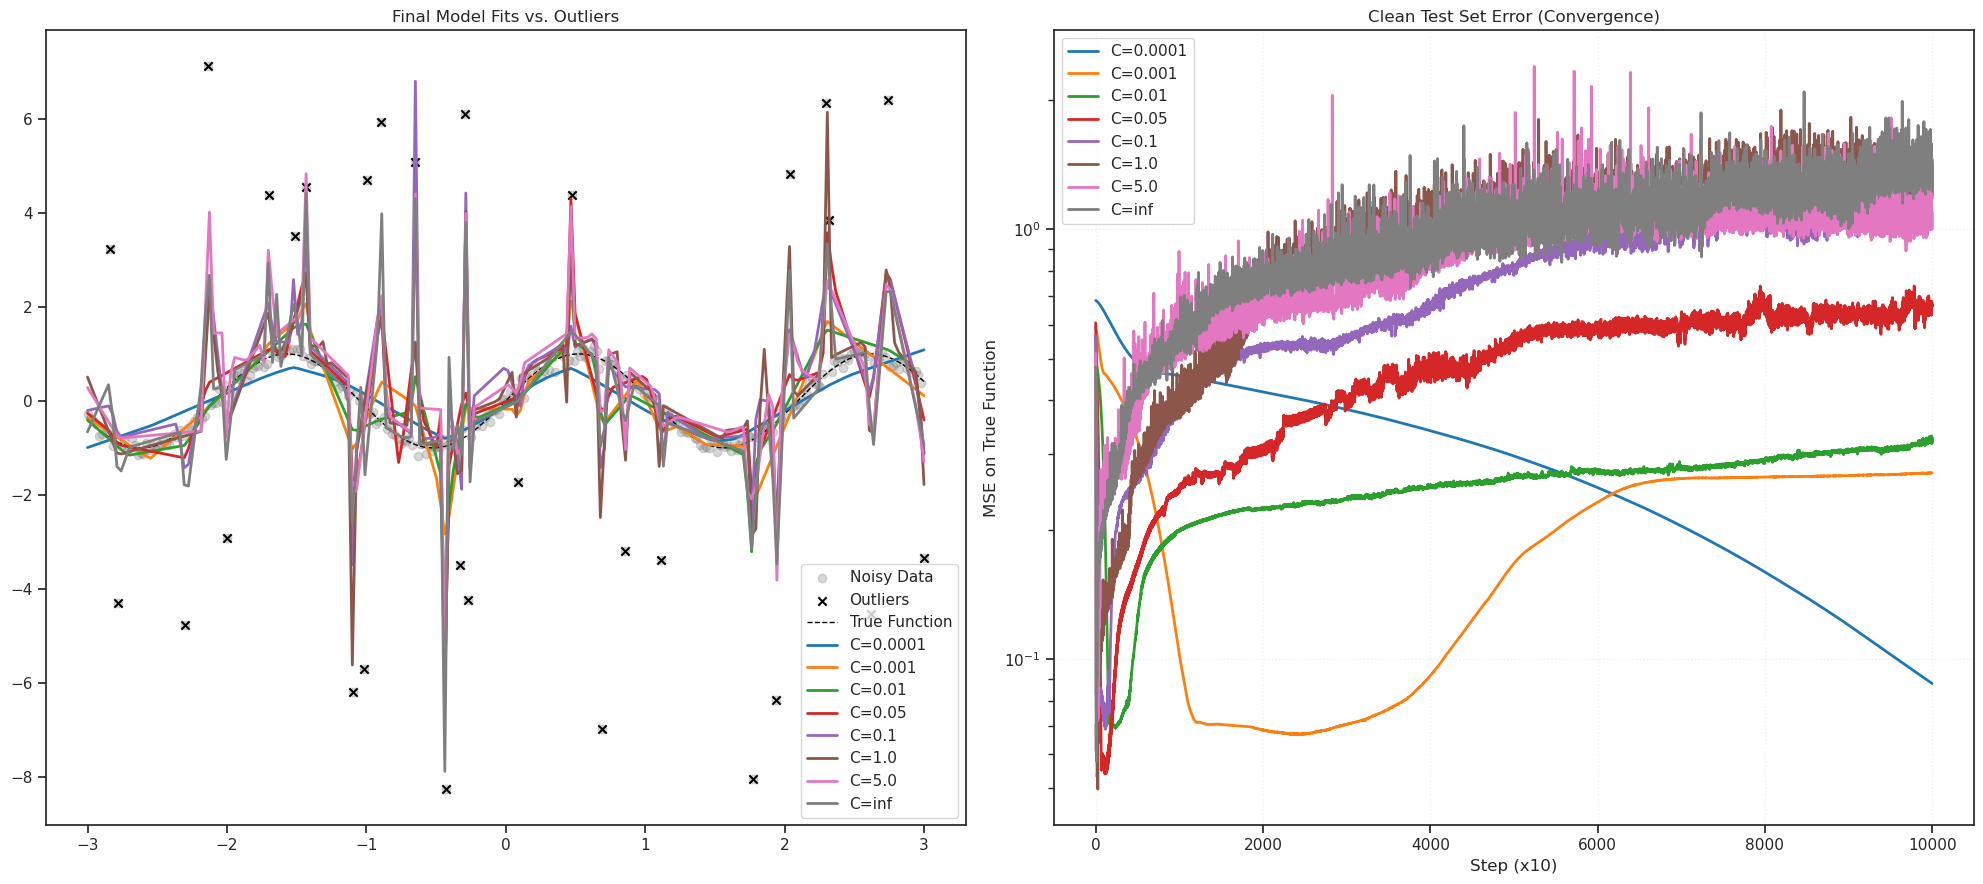

CPU times: user 5h 55min 1s, sys: 9.54 s, total: 5h 55min 10s
Wall time: 11min 6s


In [68]:
%%time


results = run_coupling_ablation(
    n_samples=300,
    outlier_ratio=0.10,
    outlier_mag_max=8.0,
    n_steps=100_000,
)

=== Experiment 4: Coupling Ablation (Robust Regression) ===

Hypothesis: C ~ 1.0 filters outliers best. C=inf overfits them. C=0.1 learns too slow.

Training with Coupling C=0.0001...

Training with Coupling C=0.001...

Training with Coupling C=0.01...

Training with Coupling C=0.05...

Training with Coupling C=0.1...

Training with Coupling C=1.0...

Training with Coupling C=5.0...

Training with Coupling C=inf...

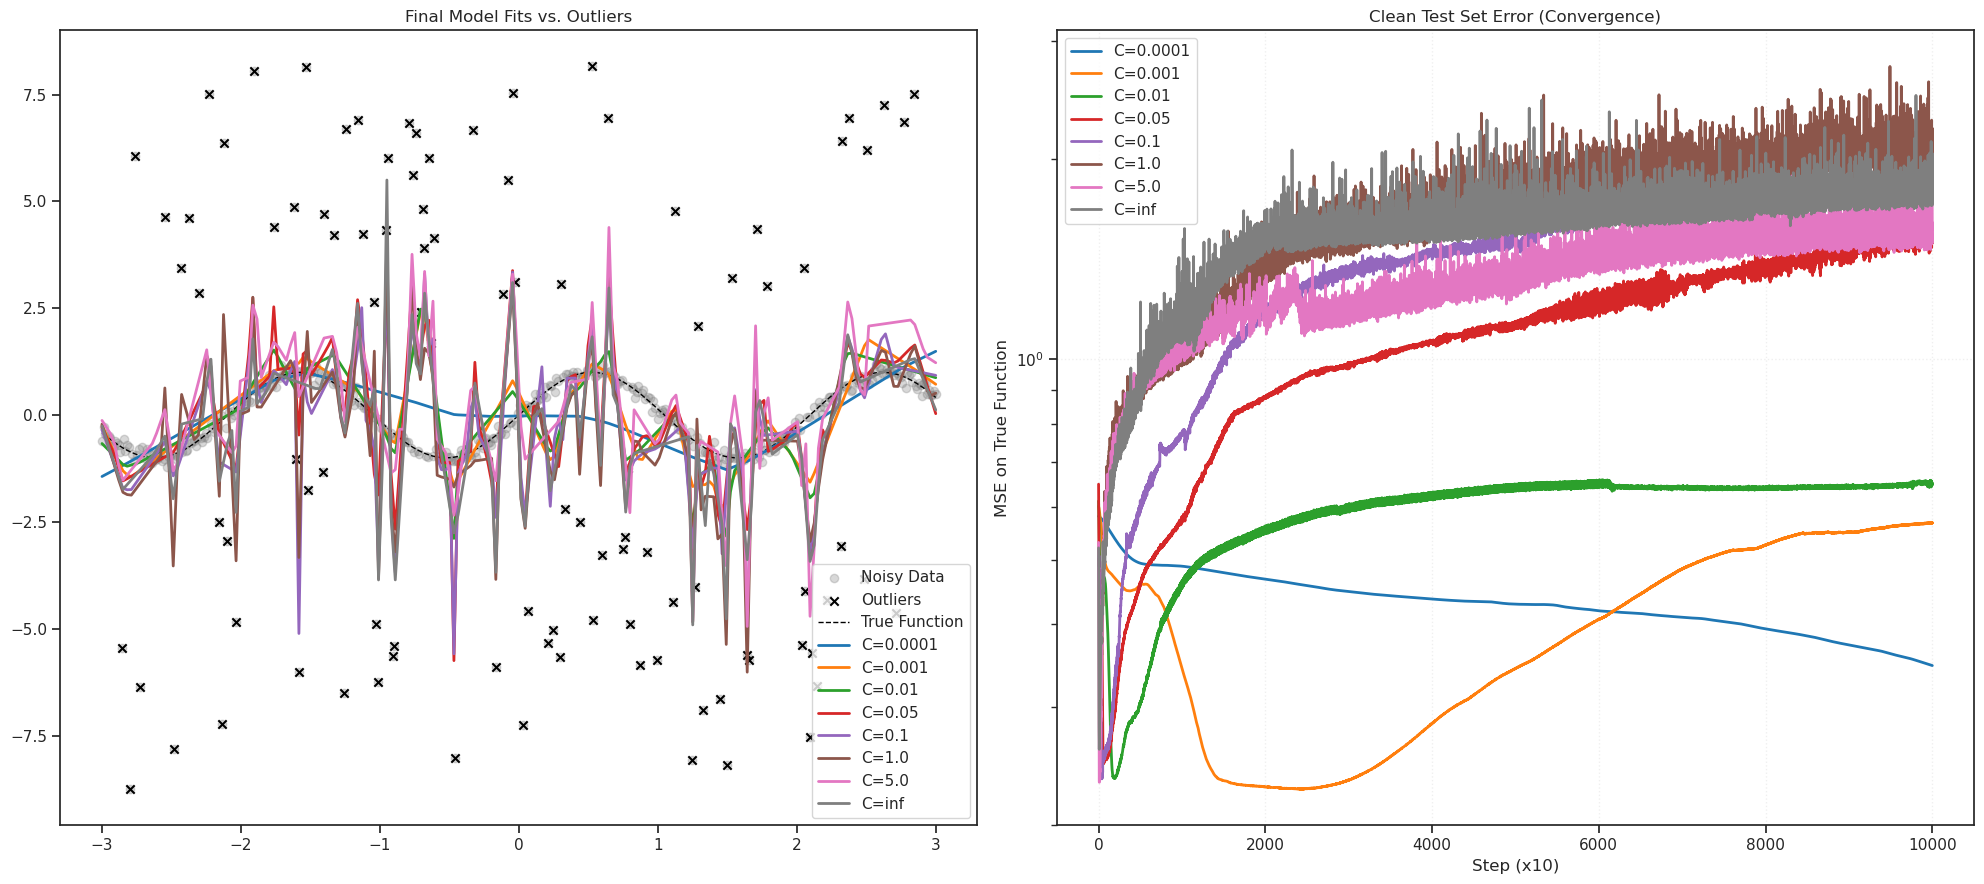

CPU times: user 6h 34min 23s, sys: 10.7 s, total: 6h 34min 34s
Wall time: 12min 20s


In [69]:
%%time


results = run_coupling_ablation(
    n_samples=500,
    outlier_ratio=0.20,
    outlier_mag_max=8.0,
    n_steps=100_000,
)

=== Experiment 4: Coupling Ablation (Robust Regression) ===

Hypothesis: C ~ 1.0 filters outliers best. C=inf overfits them. C=0.1 learns too slow.

Training with Coupling C=0.0001...

Training with Coupling C=0.001...

Training with Coupling C=0.01...

Training with Coupling C=1.0...

Training with Coupling C=100...

Training with Coupling C=inf...

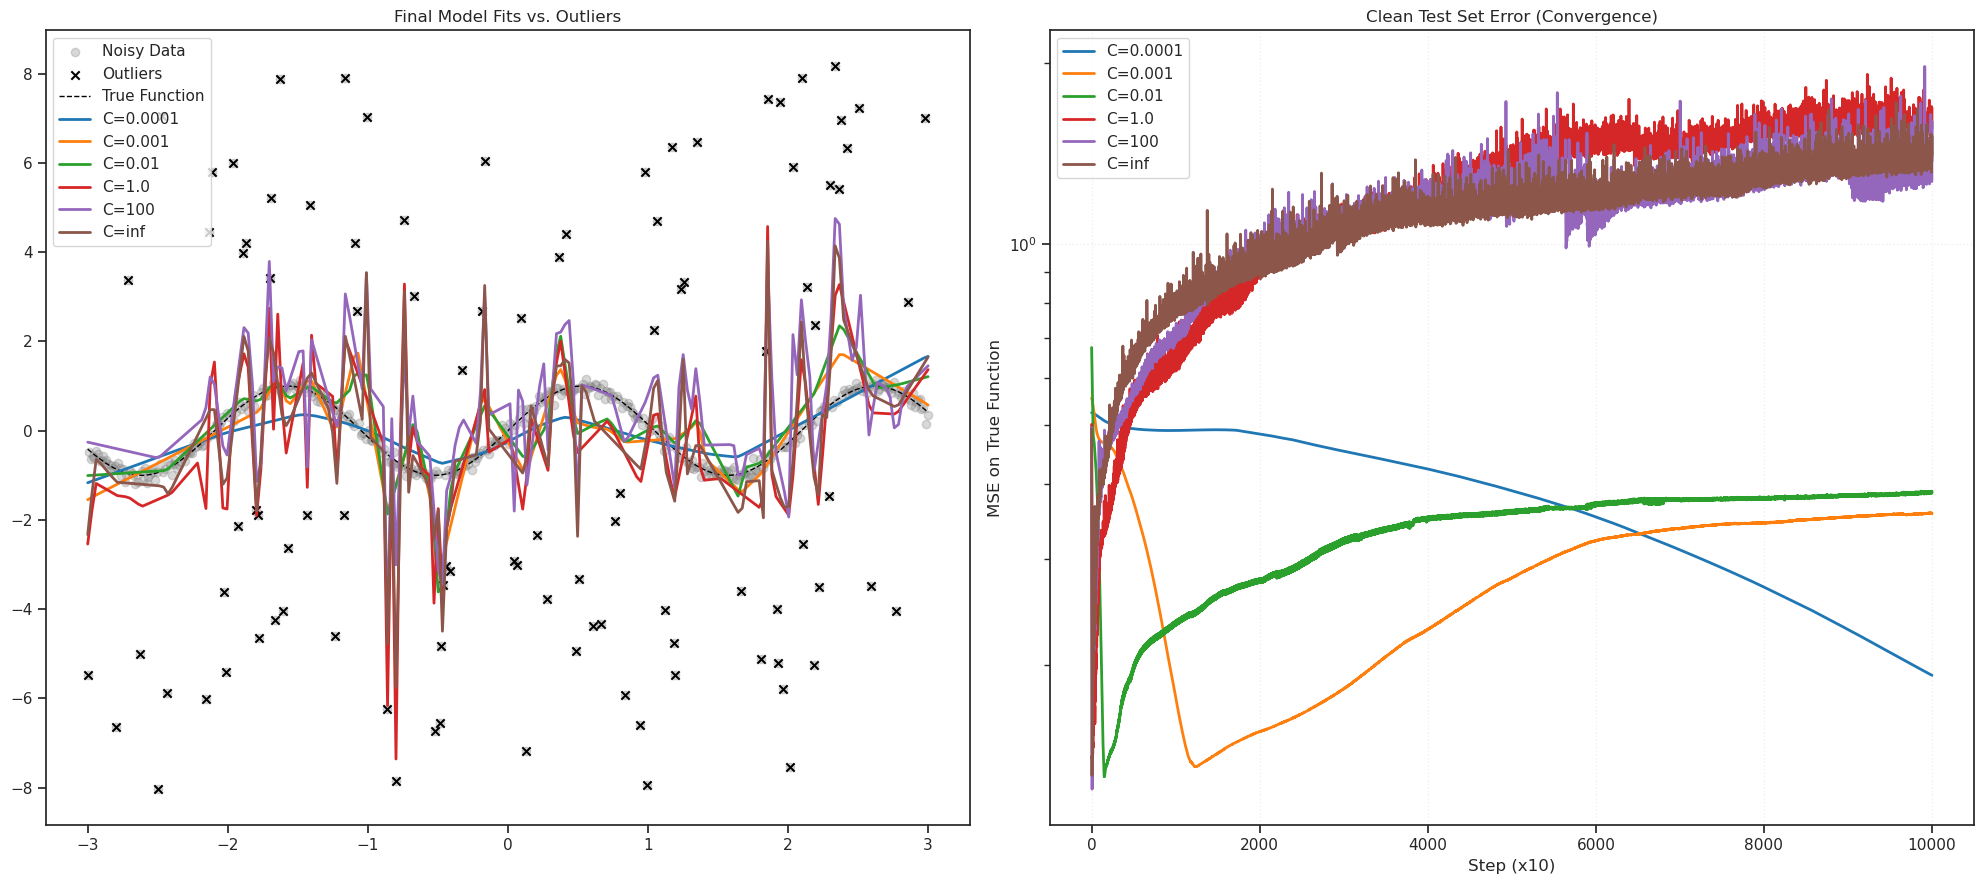

CPU times: user 6h 8min 11s, sys: 12.6 s, total: 6h 8min 24s
Wall time: 11min 32s


In [71]:
%%time


couplings = [1e-4, 1e-3, 1e-2, 1.0, 100, float('inf')]

results = run_coupling_ablation(
    n_samples=500,
    outlier_ratio=0.20,
    outlier_mag_max=8.0,
    couplings=couplings,
    n_steps=100_000,
)

=== Experiment 4: Coupling Ablation (Robust Regression) ===

Hypothesis: C ~ 1.0 filters outliers best. C=inf overfits them. C=0.1 learns too slow.

Training with Coupling C=0.0001...

Training with Coupling C=0.001...

Training with Coupling C=0.01...

Training with Coupling C=1.0...

Training with Coupling C=100...

Training with Coupling C=inf...

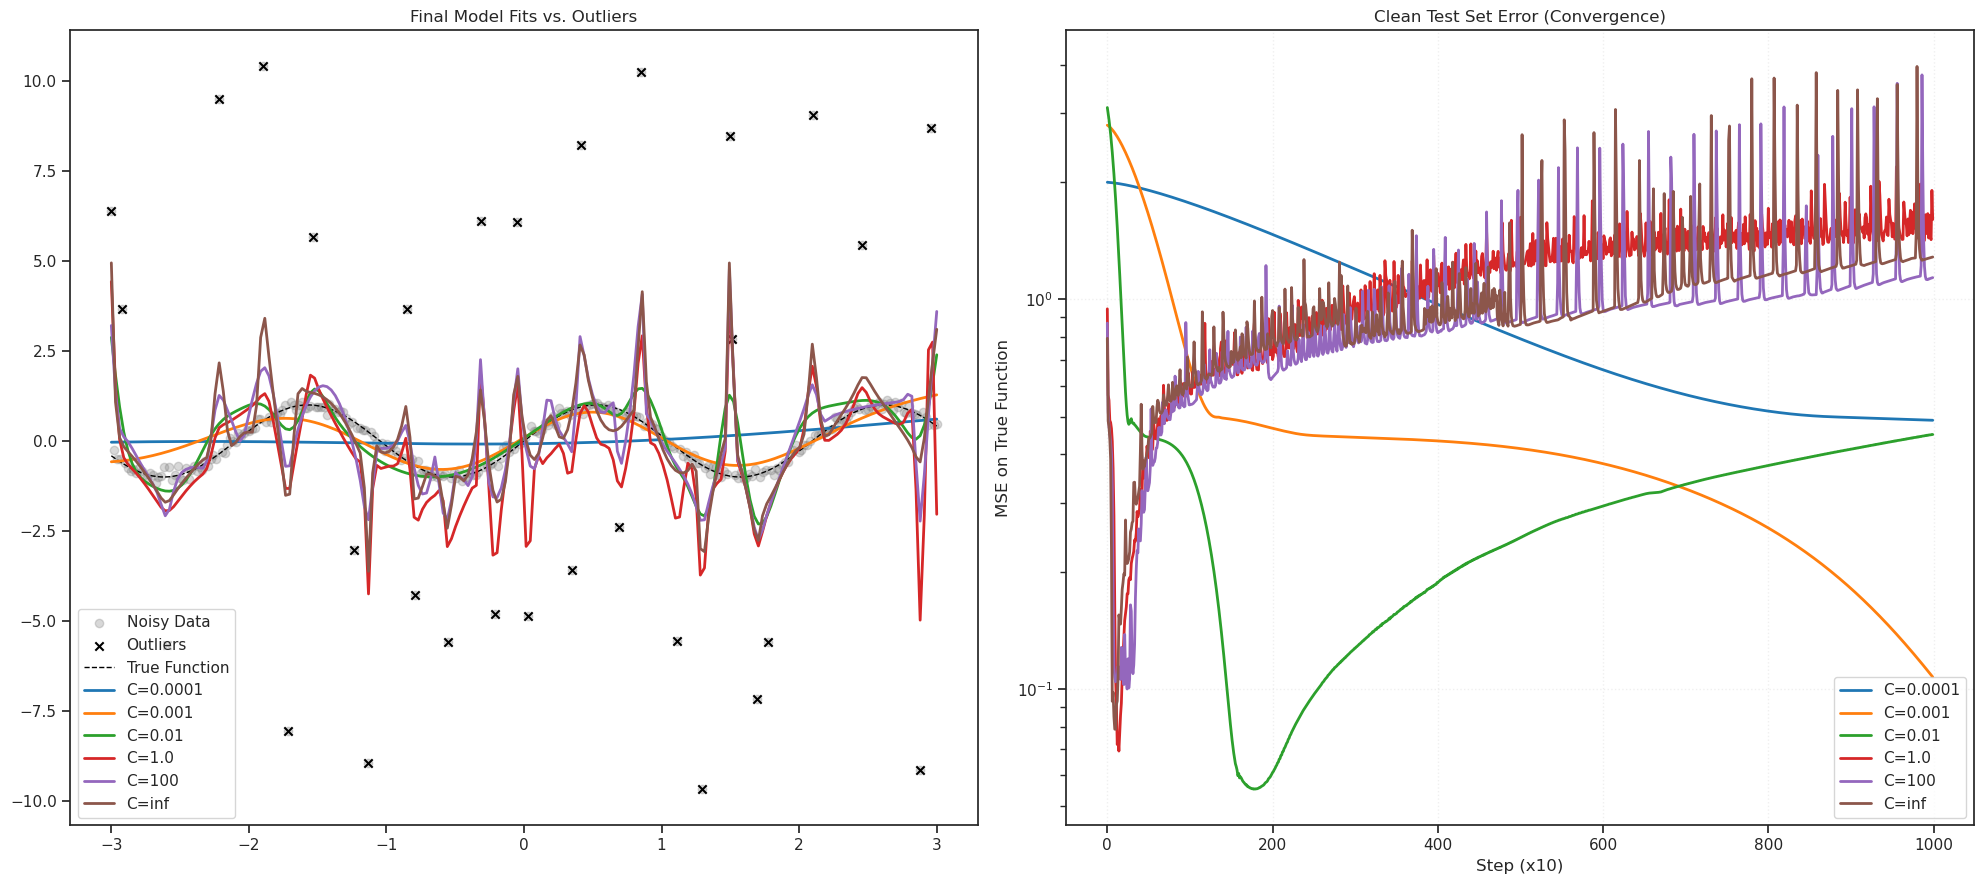

CPU times: user 48min 38s, sys: 2 s, total: 48min 40s
Wall time: 1min 31s


In [82]:
%%time


couplings = [1e-4, 1e-3, 1e-2, 1.0, 100, float('inf')]

results = run_coupling_ablation(
    n_samples=300,
    outlier_ratio=0.10,
    outlier_mag_max=10.0,
    couplings=couplings,
    n_steps=10_000,
    lr=0.01,
)

=== Experiment 4: Coupling Ablation (Robust Regression) ===

Hypothesis: C ~ 1.0 filters outliers best. C=inf overfits them. C=0.1 learns too slow.

Training with Coupling C=0.0001...

Training with Coupling C=0.001...

Training with Coupling C=1.0...

Training with Coupling C=100...

Training with Coupling C=inf...

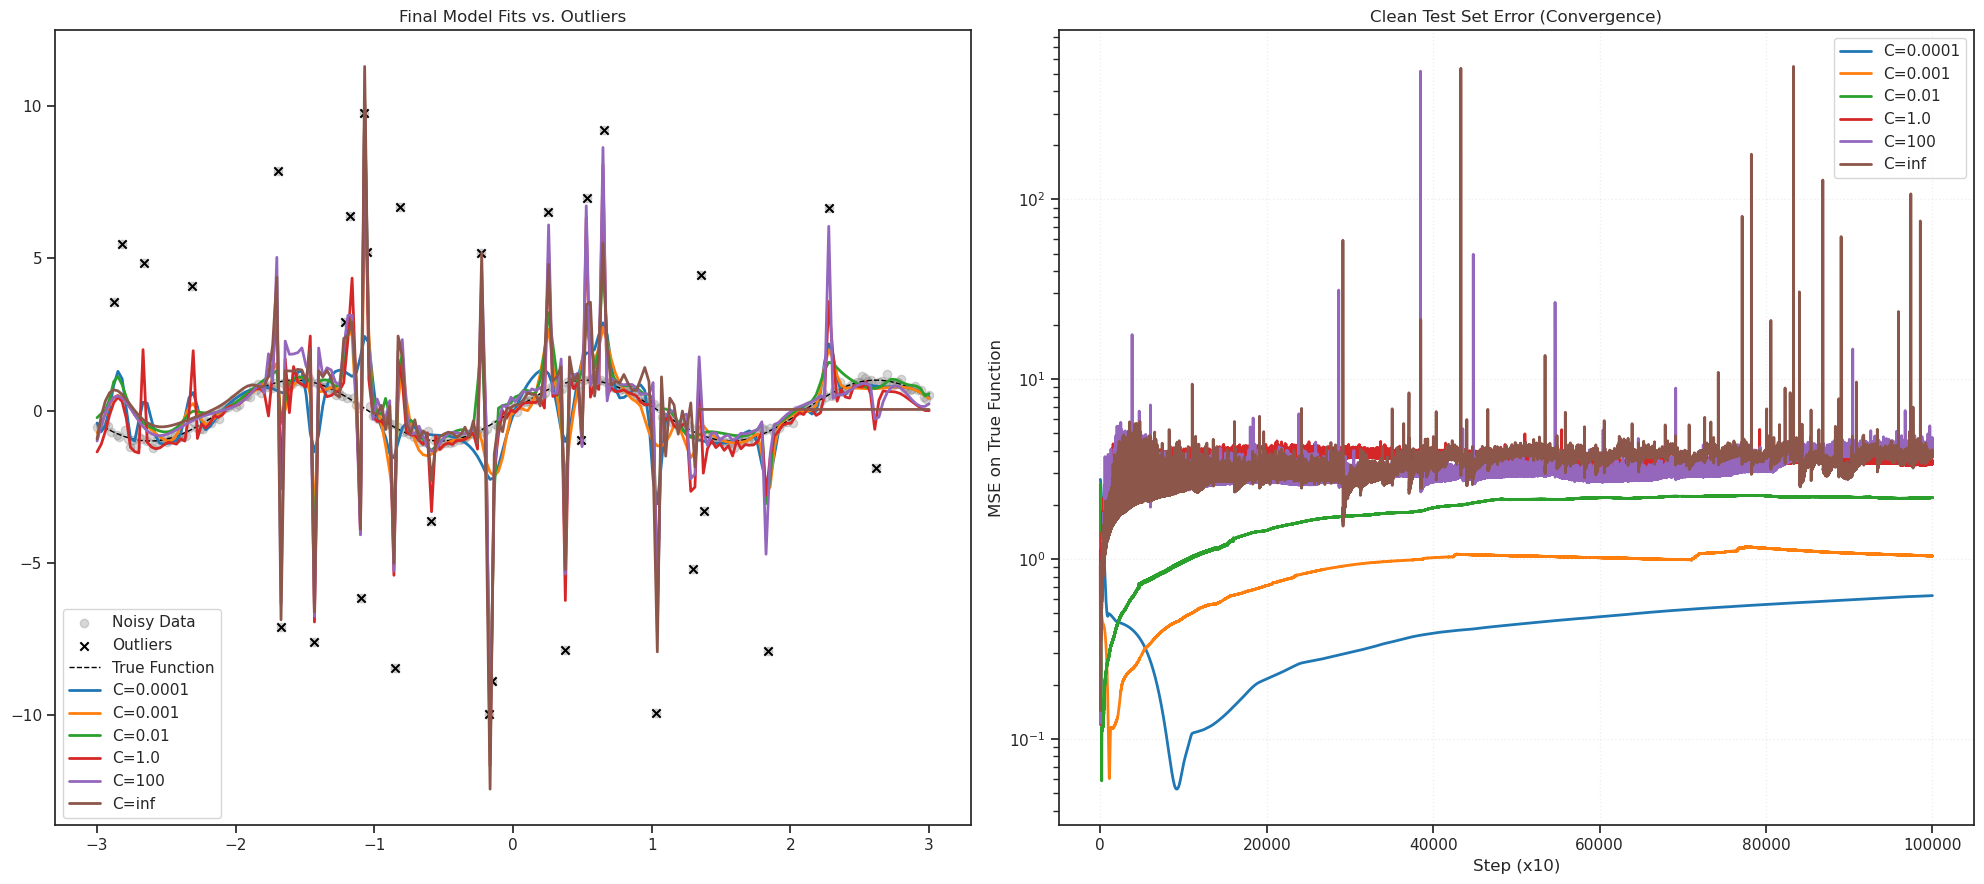

CPU times: user 4d 23h 9min 40s, sys: 2min 52s, total: 4d 23h 12min 33s
Wall time: 3h 47min 1s


In [10]:
%%time


couplings = [1e-4, 1e-3, 1e-2, 1.0, 100, float('inf')]

results = run_coupling_ablation(
    n_samples=300,
    outlier_ratio=0.10,
    outlier_mag_max=10.0,
    couplings=couplings,
    n_steps=1000_000,
    lr=0.01,
)

## Lion family

In [64]:
def run_coupling_ablation(
        n_steps=10000,
        n_samples=100,
        outlier_ratio=0.15,
        outlier_mag_max=5.0,
        masses=None,
        lr=0.01, ):
    print("\n=== Rel. Signum Mass Ablation (Robust Regression) ===")
    # print("Hypothesis: C ~ 1.0 filters outliers best. C=inf overfits them. C=0.1 learns too slow.")

    # Data
    x_train, y_train, outlier_idx = generate_data(
        n_samples=n_samples,
        outlier_ratio=outlier_ratio,
        outlier_magnitude_max=outlier_mag_max,
        outlier_magnitude_min=2.0,
    )
    
    # "Clean" test set (ground truth) to measure true performance
    x_test = torch.linspace(-3, 3, 200).unsqueeze(1)
    y_test = torch.sin(3 * x_test)

    # Configs to test
    masses = masses or [1e-4, 1e-2, 1.0, 50.0, 100, 1000]
    colors = list(sns.color_palette('tab10', n_colors=len(masses)))
    labels = [f'M={str(m)}' for m in masses]

    plt.figure(figsize=(20, 9))
    
    # Subplot 1: The fitted curves
    plt.subplot(1, 2, 1)
    plt.scatter(x_train, y_train, c='gray', alpha=0.3, label='Noisy Data')
    plt.scatter(x_train[outlier_idx], y_train[outlier_idx], c='black', marker='x', label='Outliers')
    plt.plot(x_test, y_test, 'k--', linewidth=1, label='True Function')

#     x_train = x_train.to(device)
#     y_train = y_train.to(device)
#     x_test = x_test.to(device)
#     y_test = y_test.to(device)

    results = {}

    for i, mass in enumerate(masses):
        # Simple MLP
        model = nn.Sequential(
            nn.Linear(1, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 1)
        ) # .to(device)
        
        # Note: inertial_sourcing=False matches Adam exactly when C=inf
        opt = RelativisticSignum(
            model.parameters(),
            lr=lr,
            mass=mass,
            momentum=0.9,
            weight_decay=1e-4,
        )

        losses = []
        test_errors = []

        for step in range(n_steps):
            # Full batch gradient descent
            y_pred = model(x_train)
            loss = nn.MSELoss()(y_pred, y_train)

            opt.zero_grad()
            loss.backward()
            opt.step()

            # Evaluate on clean data
            with torch.no_grad():
                test_pred = model(x_test)
                test_mse = nn.MSELoss()(test_pred, y_test)
                test_errors.append(test_mse.item())

        # Plot final curve
        with torch.no_grad():
            final_pred = model(x_test)
            plt.plot(x_test, final_pred, color=colors[i], linewidth=2, label=labels[i])

        results[labels[i]] = test_errors

        test_r = sp_stats.pearsonr(tonp(y_test.squeeze()), tonp(final_pred.squeeze())).statistic
        test_r2 = compute_r2(true=y_test, pred=final_pred)
        if test_r2 < 0:
            r2_str = 'N/A'
        else:
            r2_str = f"{np.round(test_r2 * 100)} %"
        print(f"M={mass} done...\t final test MSE = {test_mse.item():0.3f} ——— r: {test_r:0.2f}  r2: {r2_str}")

    plt.title("Final Model Fits vs. Outliers")
    plt.legend()
    # plt.ylim(-2.5, 2.5) # Zoom in to see the fit, ignore outlier range

    # Subplot 2: Test Error Curves
    plt.subplot(1, 2, 2)
    for label, errors in results.items():
        # Smoothing
        smoothed = torch.tensor(errors).view(-1, 10).mean(dim=1)
        plt.plot(smoothed, label=label, linewidth=2)

    plt.yscale('log')
    plt.title("Clean Test Set Error (Convergence)")
    plt.xlabel("Step (x10)")
    plt.ylabel("MSE on True Function")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    
    return results

=== Rel. Signum Mass Ablation (Robust Regression) ===

M=0.0 done...    final test MSE = 0.661 ——— r: 0.50  r2: N/A

M=0.01 done...   final test MSE = 1.771 ——— r: 0.56  r2: N/A

M=1.0 done...    final test MSE = 2.331 ——— r: 0.45  r2: N/A

M=50.0 done...   final test MSE = 1.667 ——— r: 0.45  r2: N/A

M=100 done...    final test MSE = 1.212 ——— r: 0.52  r2: N/A

M=1000 done...   final test MSE = 0.321 ——— r: 0.67  r2: 38.0 %

M=100000.0 done...       final test MSE = 0.554 ——— r: 0.29  r2: N/A

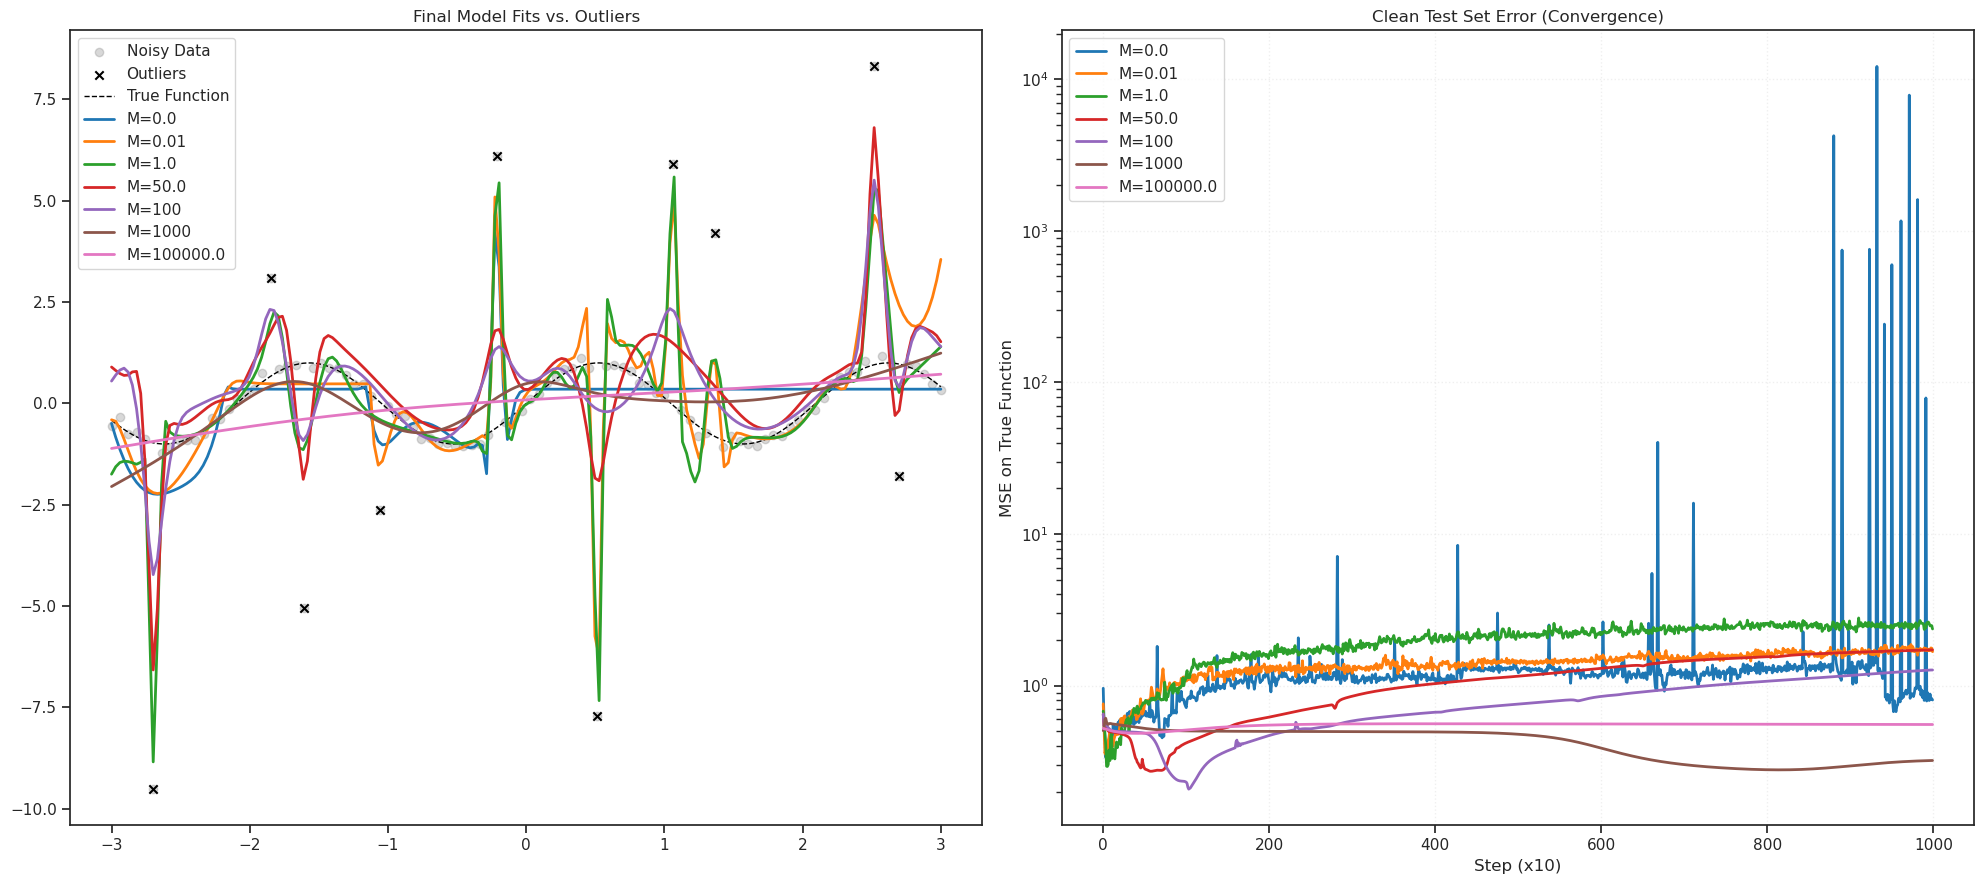

CPU times: user 27min 55s, sys: 1.37 s, total: 27min 57s
Wall time: 52.8 s


In [66]:
%%time


masses = [0.0, 1e-2, 1.0, 50.0, 100, 1000, 1e5]

results2 = run_coupling_ablation(
    n_samples=100,
    outlier_ratio=0.1,
    outlier_mag_max=10.0,
    masses=masses,
    n_steps=10_000,
    lr=0.01,
)